In [1]:
# from opticalib.ground import osutils as osu

from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import os

In [2]:
def computeRadialProfile(image, centerInPxY=None, centerInPxX=None):
    if centerInPxX is None:
        centerInPxX = image[1].shape//2
    if centerInPxY is None:
        centerInPxY = image[0].shape//2
    yCoord, xCoord= np.indices(image.shape)
    yCoord= (yCoord - centerInPxY)
    xCoord= (xCoord - centerInPxX)
    rCoord=np.sqrt(xCoord**2 + yCoord**2)
    indexR= np.argsort(rCoord.flat)
    radialDistancesSorted= rCoord.flat[indexR]
    imageValuesSortedByRadialDistance= image.flat[indexR]
    integerPartOfRadialDistances= radialDistancesSorted.astype(np.int64)
    deltaRadialDistance= integerPartOfRadialDistances[1:] - \
        integerPartOfRadialDistances[:-1]
    radialDistanceChanges= np.where(deltaRadialDistance)[0]
    nPxInBinZero= radialDistanceChanges[0]+ 1
    nPxInRadialBin= radialDistanceChanges[1:] - \
        radialDistanceChanges[:-1]
    imageRadialCumSum= np.cumsum(imageValuesSortedByRadialDistance,
                                 dtype=np.float64)
    imageSumInBinZero= imageRadialCumSum[radialDistanceChanges[0]]
    imageSumInRadialBin= \
        imageRadialCumSum[radialDistanceChanges[1:]] - \
        imageRadialCumSum[radialDistanceChanges[:-1]]
    profileInZero= imageSumInBinZero / nPxInBinZero
    profileFromOne= imageSumInRadialBin / nPxInRadialBin
    profile= np.hstack([profileInZero, profileFromOne])

    distanceRadialCumSum= np.cumsum(radialDistancesSorted)
    distanceSumInBinZero= distanceRadialCumSum[radialDistanceChanges[0]]
    distanceSumInRadialBin= \
        distanceRadialCumSum[radialDistanceChanges[1:]] - \
        distanceRadialCumSum[radialDistanceChanges[:-1]]
    distanceInZero= distanceSumInBinZero / nPxInBinZero
    distanceFromOne= distanceSumInRadialBin / nPxInRadialBin
    radialDistance= np.hstack([distanceInZero, distanceFromOne])
    return profile, radialDistance


def get_photocenter(image):
    ny, nx = image.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X,Y = np.meshgrid(x, y)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    return qx,qy 


def best_circle_fit(image,show_fit:bool=False):
    """Estimate the center coordinates and radius of a circular bright
    feature in *image*.

    Parameters
    ----------
    image : 2-D ndarray
        Input intensity map.  The algorithm finds pixels above a threshold
        (default 50%% of the maximum value) and fits a circle to their
        locations using a simple algebraic least-squares method.
    show_fit : bool
        If ``True`` generate a figure showing the input image with the
        fitted circle overlaid as a dashed blue line and the estimated
        center marked with a cross.

    Returns
    -------
    cx, cy : float
        Estimated center coordinates (x along columns, y along rows).
    radius : float
        Radius of the fitted circle in pixel units.  If the fit fails, a
        radius of ``np.nan`` is returned.
    """
    arr = np.asarray(image, dtype=np.float64)
    maxv = arr.max()
    thresh = 0.5 * maxv
    ys, xs = np.nonzero(arr >= thresh)
    if len(xs) < 3:
        cx, cy = get_photocenter(arr)
        if show_fit:
            plt.figure()
            plt.imshow(arr, origin='lower', cmap='gray')
            plt.plot(cy, cx, '+', c='C0')
        return cx, cy, 0.0

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)
    A = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
    b = x * x + y * y
    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy, c0 = c
    radius = np.sqrt(cx * cx + cy * cy + c0)

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        theta = np.linspace(0, 2*np.pi, 200)
        circle_x = cx + radius * np.cos(theta)
        circle_y = cy + radius * np.sin(theta)
        plt.plot(circle_x, circle_y, '--', c='C0')
        plt.plot(cx, cy, '+', c='C0')
        plt.xlim([cx-2.4*radius,cx+2.4*radius])
        plt.ylim([cy-2.4*radius,cy+2.4*radius])

    return cx, cy, radius


In [ ]:
def best_ellipse_fit(image, show_fit:bool=False,circle_fit=None):
    """Fit an ellipse to the brightest region of an image.

    The method thresholds the input at a fraction of the maximum value and
    fits an algebraic conic to the selected pixel coordinates.  Intensity
    values of the pixels are used as weights in the least–squares fit so that
    brighter points pull the solution harder.  The routine now starts from a
    circular estimate obtained with :func:`best_circle_fit` and then refines
    the eccentricity and orientation by solving a nonlinear weighted least
    squares problem.  If the resulting conic represents an ellipse the
    centre, major/minor semi-axes and orientation angle are returned.  When
    ``show_fit`` is ``True`` a diagnostic figure with the overlayed ellipse
    is produced.

    Parameters
    ----------
    image : 2-D ndarray
        Intensity map containing a roughly elliptical bright feature.
    show_fit : bool
        Whether to plot the fit on top of the image (dashed orange line,
        centre marked with a cross).

    Returns
    -------
    cx, cy : float
        Coordinates of the ellipse centre (x columns, y rows).
    a, b : float
        Semi-major and semi-minor axis lengths in pixels.  ``a`` is the
        larger of the two.
    theta : float
        Rotation angle of the major axis measured counter‑clockwise from
        the x-axis (columns) in radians.

    Notes
    -----
    After computing an initial circular estimate (centre and radius) the
    algorithm constructs a weighted residual function for the algebraic
    ellipse equation in terms of parameters ``(a, b, theta)`` and minimises
    it using ``scipy.optimize.least_squares``.  The pixel intensities above
    threshold act as weights.  If optimisation fails or the resulting conic
    is not an ellipse the function falls back to the circle result with
    ``a==b`` and ``theta==0``.
    """
    arr = np.asarray(image, dtype=np.float64)
    maxv = arr.max()

    # initial mask points above threshold
    thresh = 0.5 * maxv
    ys, xs = np.nonzero(arr >= thresh)

    # start from circle estimate
    if circle_fit is None:
        circle_fit = best_circle_fit(arr, show_fit=False)
    cx, cy, radius = circle_fit

    # prepare variables for optimisation
    x = xs.astype(np.float64)
    y = ys.astype(np.float64)
    weights = arr[ys, xs].astype(np.float64)
    W = np.sqrt(weights)

    def residuals(params):
        a, b, theta = params
        # enforce positive axes
        if a <= 0 or b <= 0:
            return np.ones_like(x) * 1e6
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        xrel = x - cx
        yrel = y - cy
        # rotate coordinates into ellipse frame
        xr = xrel * cos_t + yrel * sin_t
        yr = -xrel * sin_t + yrel * cos_t
        # algebraic distance from ellipse (xr/a)^2 + (yr/b)^2 - 1
        d = xr**2 / (a*a) + yr**2 / (b*b) - 1.0
        return W * d

    # initial guess: circular solution
    init = np.array([radius, radius, 0.0])
    try:
        from scipy.optimize import least_squares
        sol = least_squares(residuals, init, bounds=([1e-6,1e-6,-np.pi/2], [np.inf, np.inf, np.pi/2]))
        a_opt, b_opt, theta_opt = sol.x
    except Exception:
        # if scipy not available or optimizer fails, fallback to algebraic
        a_opt = radius
        b_opt = radius
        theta_opt = 0.0

    # ensure order a >= b
    a, b, theta = (a_opt, b_opt, theta_opt)
    if b > a:
        a, b = b, a
        theta += np.pi/2

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        t = np.linspace(0, 2*np.pi, 400)
        cos_t = np.cos(t)
        sin_t = np.sin(t)
        xe = a * cos_t
        ye = b * sin_t
        xr = cx + xe * np.cos(theta) - ye * np.sin(theta)
        yr = cy + xe * np.sin(theta) + ye * np.cos(theta)
        plt.plot(xr, yr, '--', c='C1')
        plt.plot(cx, cy, '+', c='C1')
        # draw semi-major and semi-minor axes
        dx_major = a * np.cos(theta)
        dy_major = a * np.sin(theta)
        # dx_minor = -b * np.sin(theta)
        # dy_minor = b * np.cos(theta)
        plt.plot([cx-dx_major, cx+dx_major], [cy-dy_major, cy+dy_major], ':', c='C1')
        # plt.plot([cx-dx_minor, cx+dx_minor], [cy-dy_minor, cy+dy_minor], ':', c='C1')
        plt.xlim([cx-2.4*radius,cx+2.4*radius])
        plt.ylim([cy-2.4*radius,cy+2.4*radius])
    

    return cx, cy, a, b, theta


In [4]:
path = '/mnt/libero/S331sl'


def read_fits(filename):
    hdu = fits.open(filename)
    data = hdu[0].data
    return data

pix2mm = 3.45/1000
pix2mrad = pix2mm/200*1000

In [ ]:
def get_img_from_tns(tn_list):
    img = None
    for tn in tn_list:
        try:
            filename = os.path.join(path,tn)+'.fits'
            data = read_fits(filename) #osu.load_fits(filename)
        except FileNotFoundError:
            data = read_fits(tn) #osu.load_fits(tn)
        if img is None:
            img = np.array(data,dtype=np.float64).copy()
        else:
            img += np.array(data,dtype=np.float64)
    return img

def get_radial_profiles(tn_list,cx,cy,show:bool=False,lim:int=200):
    rad_profile = None
    N = len(tn_list)
    if show:
        plt.figure()
    for tn in tn_list:        
        try:
            filename = os.path.join(path,tn)+'.fits'
            data = read_fits(filename) #osu.load_fits(filename)
        except FileNotFoundError:
            data = read_fits(tn) #osu.load_fits(tn)
        # profile, pix_dist = computeRadialProfile(np.array(data),cx,cy)
        img = data[int(cx-1.1*lim):int(cx+1.1*lim),int(cy-1.1*lim):int(cy+1.1*lim)]
        profile, pix_dist = computeRadialProfile(np.array(img),int(1.1*lim),int(1.1*lim))
        if show:
            plt.plot(pix_dist,profile,'--')
        if rad_profile is None:
            rad_profile = np.array(profile).copy()
        else:
            rad_profile = np.hstack([rad_profile,np.array(profile)])
    if show:
        plt.grid()
        plt.xscale('log')
        plt.yscale('log')
    rad_profile = rad_profile.reshape([N,len(profile)])
    return rad_profile, pix_dist
    

def analyse_tns(tn_list):
    img = get_img_from_tns(tn_list=tn_list)
    cx,cy,radius = best_circle_fit(img,show_fit=False)
    cx,cy,a,b,theta = best_ellipse_fit(img,show_fit=False)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, origin='lower', cmap='gray')
    th = np.linspace(0, 2*np.pi, 200)
    circle_x = cx + radius * np.cos(th)
    circle_y = cy + radius * np.sin(th)
    plt.plot(circle_x, circle_y, '--', c='C0')
    plt.plot(cx, cy, '+', c='C0')
    plt.title(tn_list[0])
    lim = 100 # 2.4*radius
    xlim = [cx-lim, cx+lim]
    ylim = [cy-lim, cy+lim]
    plt.xlim(xlim)
    plt.ylim(ylim)
    xticks_pos = np.linspace(xlim[0],xlim[1],int(2*lim*pix2mm*10)+1)
    xlabels = [(pos - cx) * pix2mm for pos in xticks_pos]
    plt.xticks(ticks=xticks_pos, labels=[f"{lab:1.1f}" for lab in xlabels])
    plt.xlabel('[mm]')
    yticks_pos = np.linspace(ylim[0],ylim[1],int(2*lim*pix2mm*10)+1)
    ylabels = [(pos - cy) * pix2mm for pos in yticks_pos]
    plt.yticks(ticks=yticks_pos, labels=[f"{lab:1.1f}" for lab in ylabels])
    plt.ylabel('[mm]')
    ax = plt.gca()
    ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
    ax.tick_params(axis='x', which='minor', length=2)
    ax.tick_params(axis='y', which='minor', length=2)
    plt.minorticks_on()
    plt.subplot(1,2,2)
    plt.imshow(img, origin='lower', cmap='gray')
    cos_t = np.cos(th)
    sin_t = np.sin(th)
    xe = a * cos_t
    ye = b * sin_t
    xr = cx + xe * np.cos(theta) - ye * np.sin(theta)
    yr = cy + xe * np.sin(theta) + ye * np.cos(theta)
    plt.plot(xr, yr, '--', c='C1')
    plt.plot(cx, cy, '+', c='C1')
    # draw semi-major and semi-minor axes
    dx_major = a * np.cos(theta)
    dy_major = a * np.sin(theta)
    # dx_minor = -b * np.sin(theta)
    # dy_minor = b * np.cos(theta)
    plt.plot([cx-dx_major, cx+dx_major], [cy-dy_major, cy+dy_major], ':', c='C1')
    # plt.plot([cx-dx_minor, cx+dx_minor], [cy-dy_minor, cy+dy_minor], ':', c='C1')
    eps = np.sqrt(1-b**2/a**2)
    plt.title(f'Eccentricity: {eps:1.4f}, Angle: {theta*180/np.pi:1.1f}°')
    plt.xlim(xlim)
    plt.ylim(ylim)
    xticks_pos = np.linspace(xlim[0],xlim[1],int(2*lim*pix2mm*10)+1)
    xlabels = [(pos - cx) * pix2mm for pos in xticks_pos]
    plt.xticks(ticks=xticks_pos, labels=[f"{lab:1.1f}" for lab in xlabels])
    plt.xlabel('[mm]')
    yticks_pos = np.linspace(ylim[0],ylim[1],int(2*lim*pix2mm*10)+1)
    ylabels = [(pos - cy) * pix2mm for pos in yticks_pos]
    plt.yticks(ticks=yticks_pos, labels=[f"{lab:1.1f}" for lab in ylabels])
    plt.ylabel('[mm]')
    ax = plt.gca()
    ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
    ax.tick_params(axis='x', which='minor', length=2)
    ax.tick_params(axis='y', which='minor', length=2)
    plt.minorticks_on()

    rad_profile, pix_dist = get_radial_profiles(tn_list,cy,cx,lim=lim)
    norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]

    plt.figure(figsize=(16,6))
    plt.imshow(np.log(norm_rad_profile), cmap='hot')
    plt.xlim([0, 100])
    xticks = np.linspace(0,100,12)
    yticks = np.arange(0,np.shape(norm_rad_profile)[0],5)
    plt.xticks(ticks=xticks, labels=[f'{xticks[i]*pix2mm:1.3f}' for i in range(len(xticks))])
    plt.yticks(ticks=yticks)
    ax = plt.gca()
    ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
    ax.tick_params(axis='x', which='minor', length=2)
    ax.tick_params(axis='y', which='minor', length=2)
    plt.minorticks_on()
    plt.xlabel('radial distance [mm]')
    plt.ylabel('Time [min]')
    plt.title('Azimuthal-averaged profile (log-scaled) vs time\n'+tn_list[0])
    return img, cx, cy, radius, rad_profile

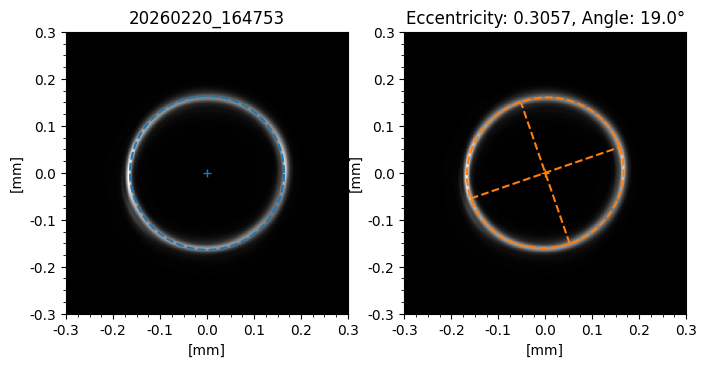

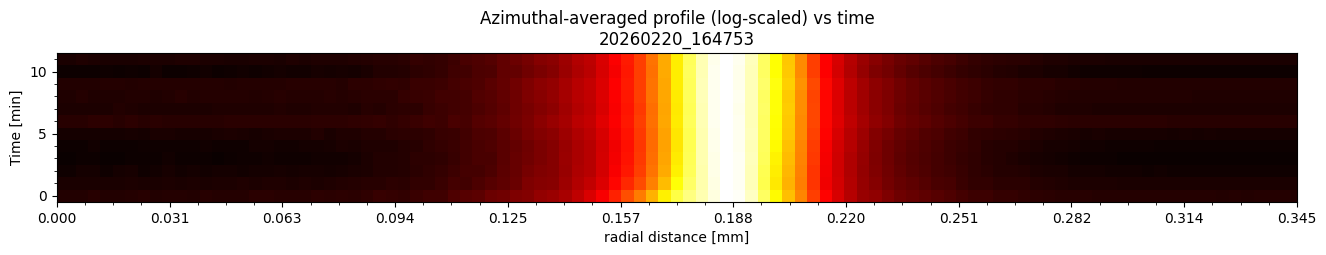

In [6]:
tn_list = ['20260220_164753','20260220_164854','20260220_164955','20260220_165055','20260220_165156',
           '20260220_165257','20260220_165358','20260220_165459','20260220_165600','20260220_165701',
           '20260220_170143','20260220_170217']

img, cx, cy, r, rad_profile = analyse_tns(tn_list)

# ex,ey,a,b,th = best_ellipse_fit(img,show_fit=True)

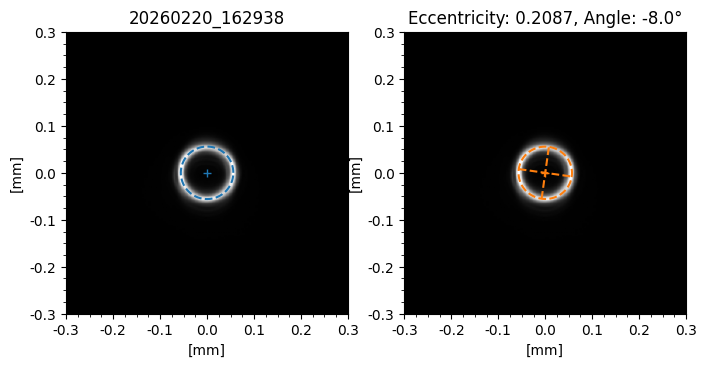

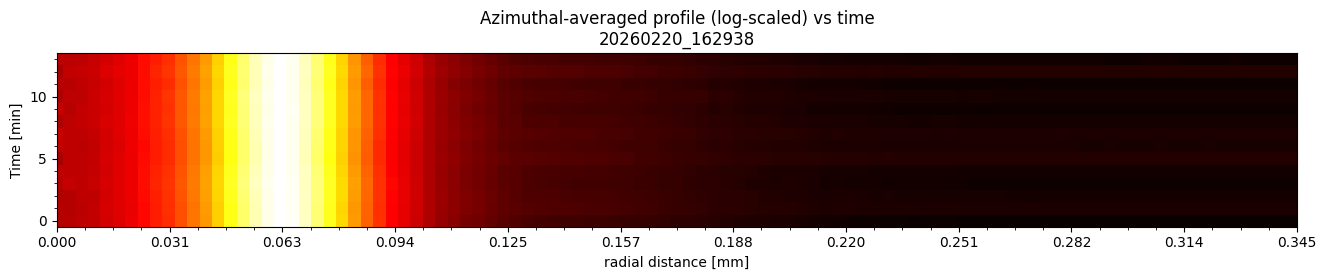

In [7]:
tn_list = ['20260220_162938','20260220_163048','20260220_163159','20260220_163310',
           '20260220_163421','20260220_163532','20260220_163643','20260220_163754',
           '20260220_163905','20260220_164016','20260220_164126','20260220_164237',
           '20260220_164348','20260220_164459']
_=analyse_tns(tn_list)

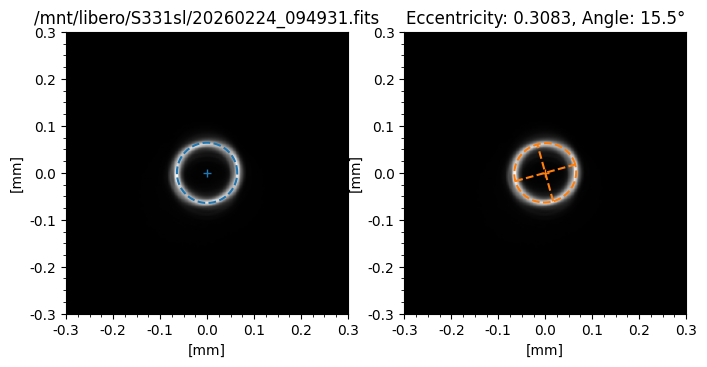

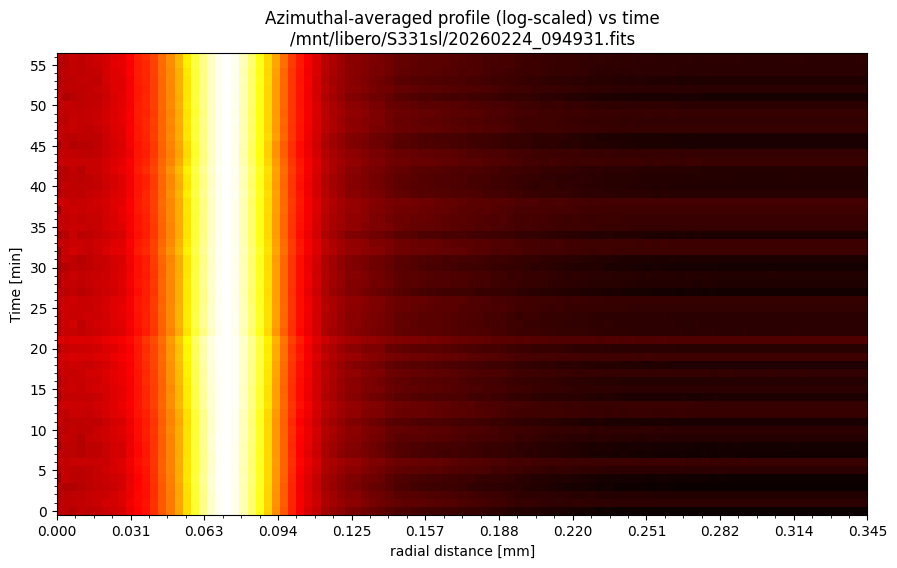

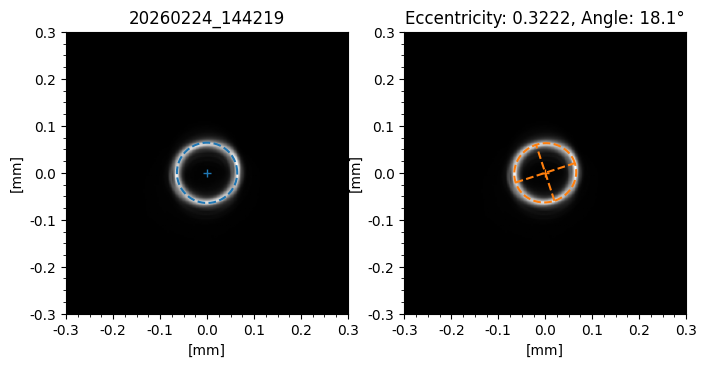

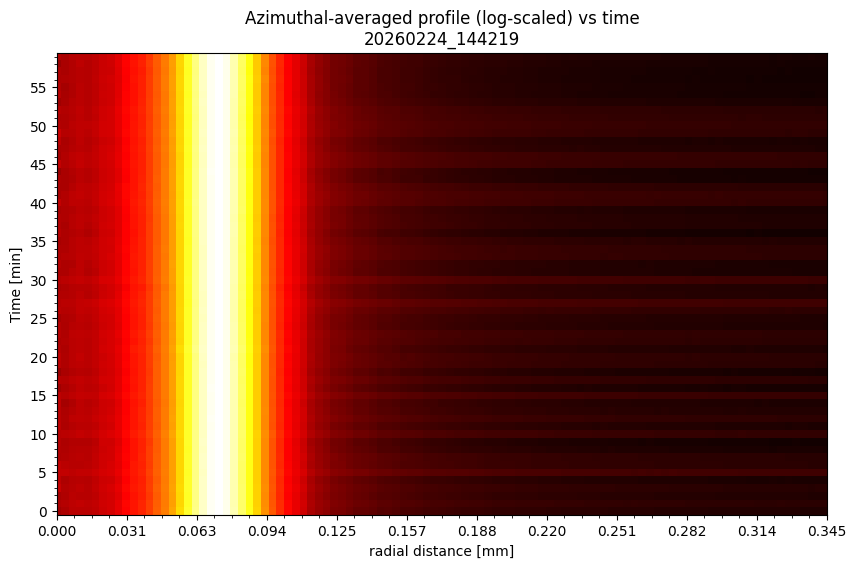

In [8]:
tnlist = ['/mnt/libero/S331sl/20260224_094931.fits',
 '/mnt/libero/S331sl/20260224_095026.fits',
 '/mnt/libero/S331sl/20260224_095121.fits',
 '/mnt/libero/S331sl/20260224_095217.fits',
 '/mnt/libero/S331sl/20260224_095312.fits',
 '/mnt/libero/S331sl/20260224_095408.fits',
 '/mnt/libero/S331sl/20260224_095503.fits',
 '/mnt/libero/S331sl/20260224_095559.fits',
 '/mnt/libero/S331sl/20260224_095654.fits',
 '/mnt/libero/S331sl/20260224_095750.fits',
 '/mnt/libero/S331sl/20260224_095845.fits',
 '/mnt/libero/S331sl/20260224_095941.fits',
 '/mnt/libero/S331sl/20260224_100036.fits',
 '/mnt/libero/S331sl/20260224_100132.fits',
 '/mnt/libero/S331sl/20260224_100227.fits',
 '/mnt/libero/S331sl/20260224_100323.fits',
 '/mnt/libero/S331sl/20260224_100418.fits',
 '/mnt/libero/S331sl/20260224_100514.fits',
 '/mnt/libero/S331sl/20260224_100609.fits',
 '/mnt/libero/S331sl/20260224_100704.fits',
 '/mnt/libero/S331sl/20260224_100800.fits',
 '/mnt/libero/S331sl/20260224_100855.fits',
 '/mnt/libero/S331sl/20260224_100951.fits',
 '/mnt/libero/S331sl/20260224_101046.fits',
 '/mnt/libero/S331sl/20260224_101142.fits',
 '/mnt/libero/S331sl/20260224_101237.fits',
 '/mnt/libero/S331sl/20260224_101333.fits',
 '/mnt/libero/S331sl/20260224_101428.fits',
 '/mnt/libero/S331sl/20260224_101524.fits',
 '/mnt/libero/S331sl/20260224_101619.fits',
 '/mnt/libero/S331sl/20260224_101715.fits',
 '/mnt/libero/S331sl/20260224_101810.fits',
 '/mnt/libero/S331sl/20260224_101905.fits',
 '/mnt/libero/S331sl/20260224_102001.fits',
 '/mnt/libero/S331sl/20260224_102056.fits',
 '/mnt/libero/S331sl/20260224_102151.fits',
 '/mnt/libero/S331sl/20260224_102247.fits',
 '/mnt/libero/S331sl/20260224_102342.fits',
 '/mnt/libero/S331sl/20260224_102438.fits',
 '/mnt/libero/S331sl/20260224_102533.fits',
 '/mnt/libero/S331sl/20260224_102628.fits',
 '/mnt/libero/S331sl/20260224_102724.fits',
 '/mnt/libero/S331sl/20260224_102819.fits',
 '/mnt/libero/S331sl/20260224_102915.fits',
 '/mnt/libero/S331sl/20260224_103010.fits',
 '/mnt/libero/S331sl/20260224_103106.fits',
 '/mnt/libero/S331sl/20260224_103201.fits',
 '/mnt/libero/S331sl/20260224_103257.fits',
 '/mnt/libero/S331sl/20260224_103352.fits',
 '/mnt/libero/S331sl/20260224_103448.fits',
 '/mnt/libero/S331sl/20260224_103543.fits',
 '/mnt/libero/S331sl/20260224_103638.fits',
 '/mnt/libero/S331sl/20260224_103734.fits',
 '/mnt/libero/S331sl/20260224_103829.fits',
 '/mnt/libero/S331sl/20260224_103925.fits',
 '/mnt/libero/S331sl/20260224_104243.fits',
 '/mnt/libero/S331sl/20260224_104338.fits']
tnlist2=['20260224_144219',
 '20260224_144320',
 '20260224_144420',
 '20260224_144521',
 '20260224_144622',
 '20260224_144722',
 '20260224_144823',
 '20260224_144923',
 '20260224_145024',
 '20260224_145124',
 '20260224_145225',
 '20260224_145325',
 '20260224_145426',
 '20260224_145526',
 '20260224_145627',
 '20260224_145727',
 '20260224_145828',
 '20260224_145928',
 '20260224_150029',
 '20260224_150130',
 '20260224_150230',
 '20260224_150331',
 '20260224_150431',
 '20260224_150532',
 '20260224_150632',
 '20260224_150733',
 '20260224_150834',
 '20260224_150934',
 '20260224_151034',
 '20260224_151135',
 '20260224_151235',
 '20260224_151336',
 '20260224_151437',
 '20260224_151537',
 '20260224_151638',
 '20260224_151738',
 '20260224_151839',
 '20260224_151939',
 '20260224_152040',
 '20260224_152140',
 '20260224_152241',
 '20260224_152341',
 '20260224_152442',
 '20260224_152543',
 '20260224_152643',
 '20260224_152744',
 '20260224_152844',
 '20260224_152945',
 '20260224_153046',
 '20260224_153146',
 '20260224_153247',
 '20260224_153347',
 '20260224_153448',
 '20260224_153548',
 '20260224_153648',
 '20260224_153749',
 '20260224_153849',
 '20260224_153950',
 '20260224_154051',
 '20260224_154151']

_=analyse_tns(tnlist)
_=analyse_tns(tnlist2)

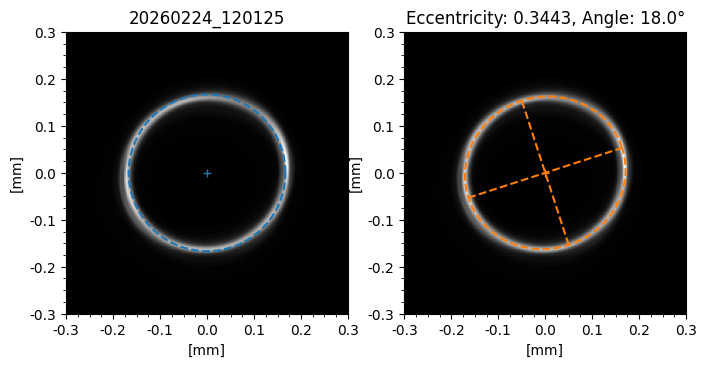

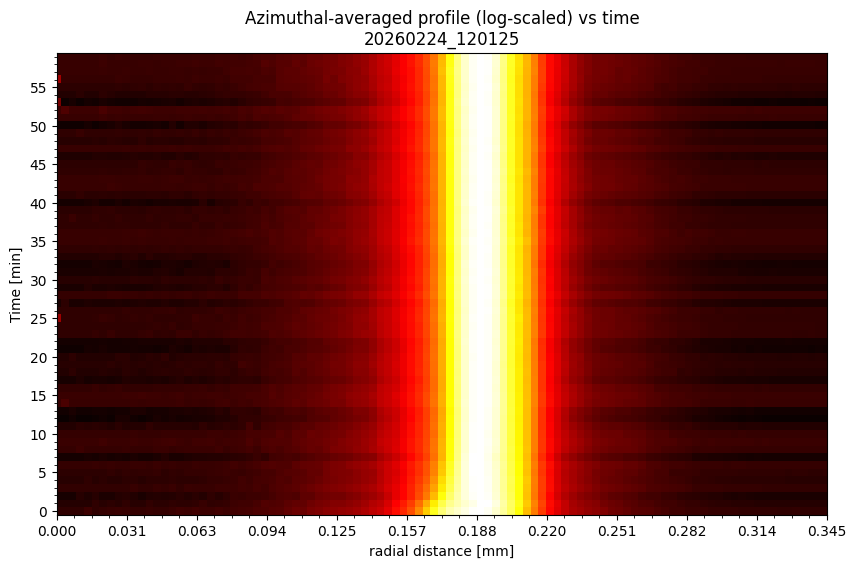

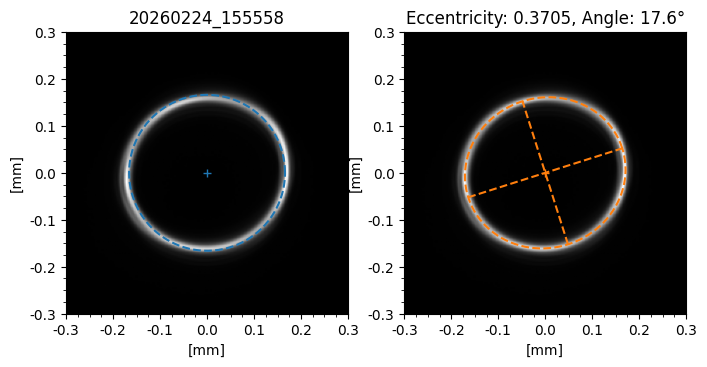

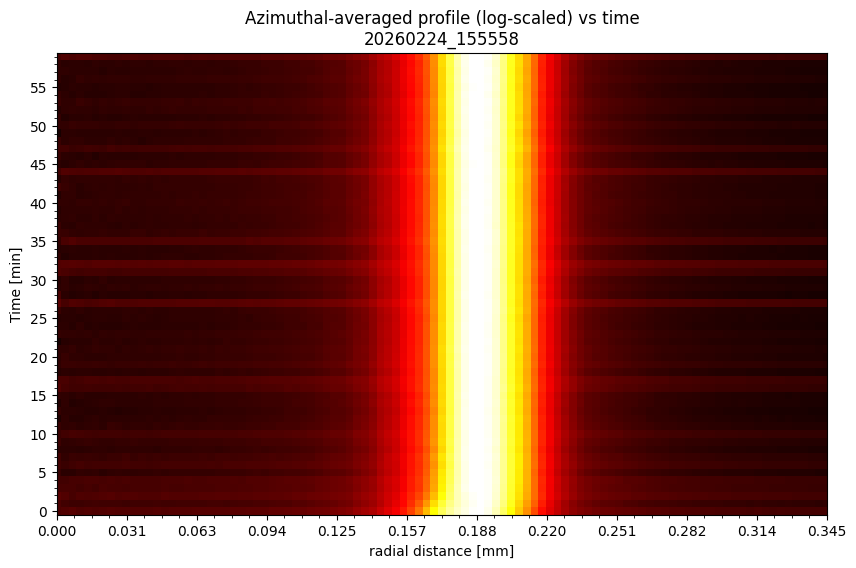

In [9]:
tnlist = ['20260224_120125',
 '20260224_120226',
 '20260224_120326',
 '20260224_120427',
 '20260224_120527',
 '20260224_120628',
 '20260224_120728',
 '20260224_120829',
 '20260224_120929',
 '20260224_121030',
 '20260224_121130',
 '20260224_121231',
 '20260224_121331',
 '20260224_121432',
 '20260224_121532',
 '20260224_121633',
 '20260224_121733',
 '20260224_121834',
 '20260224_121934',
 '20260224_122035',
 '20260224_122135',
 '20260224_122235',
 '20260224_122336',
 '20260224_122436',
 '20260224_122537',
 '20260224_122637',
 '20260224_122738',
 '20260224_122838',
 '20260224_122938',
 '20260224_123039',
 '20260224_123139',
 '20260224_123240',
 '20260224_123341',
 '20260224_123441',
 '20260224_123542',
 '20260224_123642',
 '20260224_123743',
 '20260224_123843',
 '20260224_123944',
 '20260224_124044',
 '20260224_124145',
 '20260224_124245',
 '20260224_124346',
 '20260224_124446',
 '20260224_124547',
 '20260224_124647',
 '20260224_124747',
 '20260224_124848',
 '20260224_124948',
 '20260224_125049',
 '20260224_125149',
 '20260224_125248',
 '20260224_125348',
 '20260224_125449',
 '20260224_125550',
 '20260224_125650',
 '20260224_125751',
 '20260224_125851',
 '20260224_125951',
 '20260224_130052']
tnlist2 = ['20260224_155558',
 '20260224_155658',
 '20260224_155759',
 '20260224_155859',
 '20260224_160000',
 '20260224_160100',
 '20260224_160201',
 '20260224_160301',
 '20260224_160402',
 '20260224_160502',
 '20260224_160603',
 '20260224_160703',
 '20260224_160804',
 '20260224_160904',
 '20260224_161005',
 '20260224_161105',
 '20260224_161206',
 '20260224_161306',
 '20260224_161407',
 '20260224_161508',
 '20260224_161608',
 '20260224_161709',
 '20260224_161809',
 '20260224_161909',
 '20260224_162010',
 '20260224_162111',
 '20260224_162211',
 '20260224_162312',
 '20260224_162412',
 '20260224_162513',
 '20260224_162613',
 '20260224_162714',
 '20260224_162814',
 '20260224_162915',
 '20260224_163015',
 '20260224_163116',
 '20260224_163216',
 '20260224_163317',
 '20260224_163417',
 '20260224_163518',
 '20260224_163618',
 '20260224_163719',
 '20260224_163819',
 '20260224_163920',
 '20260224_164020',
 '20260224_164121',
 '20260224_164221',
 '20260224_164322',
 '20260224_164422',
 '20260224_164523',
 '20260224_164623',
 '20260224_164723',
 '20260224_164824',
 '20260224_164925',
 '20260224_165025',
 '20260224_165125',
 '20260224_165226',
 '20260224_165327',
 '20260224_165427',
 '20260224_165528']

_=analyse_tns(tnlist)
img,_,_,_,_=analyse_tns(tnlist2)
